<img src = "https://files.realpython.com/media/Variables-in-Python_Watermarked.e1578a030053.jpg" align = right width = 500>

# Data 765: Python Fundamentals for Data Science
## Lecture 2 | Data Structure I
### Instructor: Yinxian Zhang | QC Sociology

---

# Table of Contents

<div class = "alert alert-info">

1. [An Introductory Example](#1)<br>
2. [Variables and Objects](#2)<br>
    2.1 [Variable Assignments](#2.1)<br>
    2.2 [Object References](#2.2) <br>
    2.3 [Variable Names](#2.3) <br>
3. [Basic Data Types & Operations](#3) <br>
    3.1 [`int` and `float`](#3.1) <br>
    3.2 [`bool` and `None`](#3.2) <br>

</div>
<hr>

# An Introductory Example <a id=1></a>

Last week when we introduced Jupyter Notebook, I included an example at the bottom of the `.ipynb` file. For some of you, that might be the first Python program you saw. 

Let's take a closer look at the program:

1984412.515657548


<AxesSubplot:>

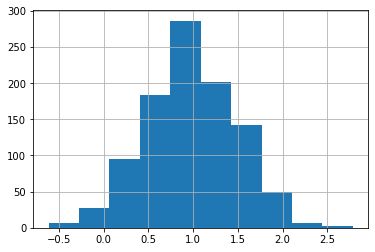

In [1]:
# a revised example from last week:

## prepare packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## set parameters
np.random.seed(123)
N = 1000

## generate random data
d = {'x': np.random.normal(1, 0.5, N), 'y': np.random.normal(1, 0.5, N)}
df = pd.DataFrame(data=d)

## get the sum of the random data
ans = 0
for x in d['x']:
    for y in d['y']:
        ans += x + y
print(ans)

## draw a simple histogram to show the distribution of x
df.x.hist()

### What did we see in this short program?

1. dark green words starting with one or more `#` sign : comments / documentation
```python
## which looks like this
# comments explainning in natural language what a command or program is doing.
# They will be ignored during the execution of the program. 
```

2. black fonts: object names (variables/functions/more)
```python
N = 100
df = pd.DataFrame(data=d)
```

3. light green numbers: `int` or `float`
```python
1 + 0.1 == 1.1
```

4. purple symbols: variable assignments or arithmetic/logical operations 
```python
x + y
a = (1 + 2 - 3 * 4 / 5) & (2.5 % 3 == 4)
```

5. bold green characters: reserved Python keywords; light green characters: built-in functions.
```python
for x in d['x']:
     print('something')
```

6. red fonts in quotation marks: strings
```python
'x', 'Lecture1.ipynb', 'Yinxian Zhang'
```

7. And, lastly, emptiness: **four white spaces**, a.k.a. **indentations** in Python:<br>
It is a critical part of Python syntax, and wrong placements of indentations may lead to `IndentationError`s.

---
# Variables and Objects <a id=2></a>

<div class = "alert alert-info">
    
<b>Acknowledgement:</b>
<br>

Some examples and illustrations of this section are drawn from the [RealPython Online Tutorial: Variables in Python](https://realpython.com/python-variables/). Follow the link to see more examples! <br>

</div>

In Python, an object usually has a name and it stores information about its value (data), the type of the data, and more. Let's focus on names and values first: 

## Variable Assignments <a id=2.1></a>

When you assign a name to an object (it could be a very complex object, such as a complex function, a research article, or even an entire dataset), you create a variable, and later you can easily **access the object just by calling its name.**

The variable assignment is simply done with a `=` (single equal sign, very different from `==` double equals)

In [2]:
a = 765              # you assigned the number 765 to a variable named `a`. 

Note that, **you would not see any output** after the assignment. You computer simply remembers that, the name `a` is assigned to the number `765`. 

If you want to check the content of `a`, you need to call it, or `print` it to the console. 

In [3]:
a

765

In [4]:
print(a)

765


You can do variable assignment one at a time, but if you need multiple variables with the same value, you can also do a chained assignment:

In [5]:
b = c = 800

In [6]:
print(b)
print(c)

800
800


In [ ]:
#b 
#c
#b c              # wrong syntax!!

## Object References <a id=2.2></a>

What is actually happening when you make a variable assignment? 

Recall that when you create a variable, essentially you just connect a name to an object with a signle equal sign `=`. 

In other words, a variable is simply a symbolic name that is a **reference** or **pointer** to an object. You may refer to the object by its name, but **the data itself is contained within the object.**

Let's consider the example below:

In [8]:
n = 300

<img src='https://files.realpython.com/media/t.2d7bcb9afaaf.png' align = Left width=300>

What would happen when you assign another variable name, `m`, to the variable `n`? 

Essentially, this is equal to the chained assignment: `m = n = 300`

In [9]:
m = n                   

This is probably counter-intuitive, but this new assignment does **not** copy and paste the object `300`, i.e. it does not create a new object of the same data. 

Instead, it simply creates **a new reference or an alias, `m`, which points to the same object that `n` points to**.

<p style="color:red;">Remember: <br>
<code>m</code> does not point to <code>n</code>. <br>
<code>m</code> does not point to a copy of the object <code>300</code>. <br> 
<code>m</code> directly points to the original object <code>300</code>itself!</p> 

<img src='https://files.realpython.com/media/t.d368386b8423.png' align = Left width=500>

Now, suppose you would like to change the assignment of `m`, what would happen?

In [10]:
m = 400

In [11]:
print(m)
print(n)

400
300


As you can tell, Python creates a new object of the number `400`, and `m` becomes the pointer to it. 

In other words, the variable `m` got updated, and its original value got overwritten. 

<p style="color:red;">However, the variable <code>n</code> is not affected. It still points to <code>300</code>.</p>

<img src='https://files.realpython.com/media/t.d476d91592cd.png' align = Left width=500>

#### Right now, you just need to understand that an alias is a second name for an object. However -- just a heads up -- it will get trickier as we learn more, and aliasing is often associated with hard-to-find bugs.

Finally, what would happen if you also change the assignment of `n`? 

In [ ]:
n = 'foo'                # a string object

Now Python creates a string object, "foo", and `n` becomes the reference to it. 

Then what about the number `300`? What happened to it?

<img src='https://files.realpython.com/media/t.344ab0b3aa8c.png' align = Left width=500>

The number `300` becomes an **orphaned object**, meaning that it losts its handle(s)/name(s), and there is no longer any reference to it. **Accordingly, we no longer have access to it.** 

Somewhat similar to the story told by the Disney movie *Coco*: **an object stays alive as long as there is at least one reference to it.**

When nobody remembers the name to an object, i.e. the number of references to an object drops to zero, its lifetime is over. Python will notice this, and will start a process called **garbage collection** which reclaim the allocated memory of the orphaned object so it can be used for something else. 

### Object id:

Does it mean that as long as two variables have the same value, they are pointing to the same object? 

**No, not necessarily.** Sometimes, multiple variables may display the same value, but they are references to different objects. How can we tell whether they are the same object or not? 

The built-in function `id()` can shows us a number that uniquely identifies an object. Just like a person's id card, no two objects will have the same id number when their lifetimes overlap. 

_However, if an object dies, its id number may be reclaimed for other objects._

In [ ]:
n = 300
m = 300

In [ ]:
id(n)

In [ ]:
id(m)

In [ ]:
k = l = 300

In [ ]:
id(k)

In [ ]:
id(l)

<div class = "alert alert-warning">
<b> Takeaway: </b> <br>
<br>
Variables are just names pointing to Python objects. <br>
An object can have multiple names/aliases. <br>
But a name only refers to one object at a given time. <br>
If multiple variables display the same value, they may or may not point to the same object. We can verify it using the built-in function <code>id()</code>.
</div>

## Variable Names <a id=2.3></a>

What variable names can you give to your objects? 

Naming can be very flexible in Python, as long as you follow the rules below：

- names can be any length.
- can consist of uppercase letters (A-Z), lowercase letters (a-z), digits (0-9), underscore (_), and even unicode characters (**python3 only**). But most of other punctuations and symbols are not allowed!
- names are **case sensitive**.
- names cannot begin with a digit.
- names cannot be Python reserved keywords. 

All of the following are valid variable names:

In [ ]:
cn = 765
coursenumber1 = 765
CourseNumber1 = 765
cOuRsEnuMBeR1 = 765
course_number1 = 765
_course1 = 765
course1_ = 765
_course1_ = 765
课程 = 765

Which style is preferred? While some names are ugly and do not make much sense, this is largely a personal preference. 

The [PEP8: Style Guide for Python Code](https://www.python.org/dev/peps/pep-0008/) recommends us to use descriptive names for variable and function names, and spell them as **snake case**, i.e. words separated by underscores, for example:

`course_number`<br>
`number_of_students`

Meanwhile, some names are simply not allowed. They either start with digits or are identical to Python reserved keywords.

In [ ]:
1course_number = 765

In [ ]:
for = 'a Python reserved keyword'

What are Python reserved keywords? 

Recall that you have seen some **green bold characters** in our first Python program. Python reserves a small set of keywords for special functionality, such as the `if...else...` control flow. You cannot use these words as your variable names. **Note that these reserved words are case-sensitive.**

Let's check the list of reserved keywords in Python 3.8:

In [ ]:
help("keywords")

Note that other green characters (non-bold) most likely refer to Python built-in functions like `print()`, `help()`, `id()`. While you can use these names to create variables, it is highly discouraged, as you would not be able to use the built-in functions if their names are used for other variables. 

<div class = "alert alert-warning">
<b> Takeaway: </b> <br>
<br>
Stay away from special words in Python when you name your variables. <br>
How do you know they are special? <br>
<p style="color:green;">They are green! Either <b>bold green</b> (reserved keywords) or light green (built-in function names).</p><br>
</div>

---
# Basic Data Types & Operations <a id=3></a>

In the above section, we mentioned that a Python object has its name (variable name), value (data), and **type**. We have seen different types of Python objects, such as numbers (`765`, `0.3`) and texts (`'a Python reserved keyword'`). We can use a built-in function `type()` to check the type of any given Python object. 

In [ ]:
type(765)

In [ ]:
type(0.1)

As you see, numbers are classified into different types in Python: `int` and `float` are two of the most basic numeric types. While there are more complex numeric types, knowing the basic ones can already keep you going for a while: 

## `int` and `float` <a id=3.1></a>

The two types are straightforward:

`int`: integers, i.e. whole numbers. <br>
`float`: floating point numbers, i.e. real numbers.

Practically, the presence of a decimal point `.` is the (only) sign of a `float`. 

In [ ]:
a = 1
type(a) 

In [ ]:
b = 1.0
type(b)

When you do arithmetic operations between `int` and `float`, the output is always `float`.

In [ ]:
div = 123 / 1.23        # 100
add = 0.1 + 0.9         # 1

print(type(div))
print(type(add))

### Type Conversions

We can use a few built-in functions to convert an `int` to a `float`, and vice versa. But note that when you convert `float` to `int`, it's likely that you need to **round** the floating number to a whole number in certan ways!

In [ ]:
float(3)

In [ ]:
int(1.78)                    # int() only keeps the integer part, and drops anything after the decimal point.          

In [ ]:
round(1.78)                  # round() is more flexible in rounding

In [ ]:
round(1.78, 1)               # specify how many digits to keep after the decimal point.

In [ ]:
# check documentation of the built-in function

help(round)

#?round  

You may also want to check out `math.ceiling` and `math.floor` in the `math` package to learn more about how to round numbers up or down. 

### Operations on `int` and `float`

We have seen simply addition (+), subtraction (-), multiplicaion (*) and division (/) operations on numbers. They are straightforward. 

There are some less common operations:

In [ ]:
# int division

10 // 3                 

In [ ]:
# modulo operation

10 % 3                    # returns the remainder

In [ ]:
# exponential operation

3 ** 3

In [ ]:
# comparisons:

5 < 4

In [ ]:
3 == 3

In [ ]:
7 != 8

#### Here is a summary of the common operators you can use:

| **Arithmetic Operators**                          | **Comparison Operators**       |
|:--------------------------                        | :------------------------------|
| `+` `-` `*` `/`                                   |a `>` b,  a `<` b               |
|a `//` b &rarr; **int** division                   |a `>=` b, a `<=` b              |
|a `%` b &rarr; the **remainder**                   |a == b &rarr; **equality** test |
|a `**` b &rarr; a to the **power** of b            |a `!=` b &rarr; **inequality** test|


### A special caveat of `float`: 

There is a particular issue with `float` in not only python but virtually all computer languages:

In [ ]:
0.1 + 0.1 + 0.1

Why is this the case? What's going on??



We encountered a problem called [**floating-point errors**](https://docs.python.org/3/tutorial/floatingpoint.html), which is associated with the [binary representation](https://en.wikipedia.org/wiki/Binary_number) of numbers in computers.

When computers perform calculations, they first convert decimal numbers (base 10) to binary (base 2), then perform calculations, then convert the results back to decimal. But some fractions cannot be stored exactly in binary, so we may see small rounding errors in outputs.

<div class = "alert alert-warning">
<b> Takeaway: </b> <br>
<br>
Be careful with float, particularly when you are doing comparisons (e.g. equality test)
</div>

In [ ]:
0.1 + 0.1 + 0.1 == 0.3

In [ ]:
## roundabout: compare the difference of floating numbers with a very very small number.

abs(0.1 + 0.1 + 0.1 - 0.3 ) < 0.00001

---
Finally, let's move on to Booleans and NoneType.

## `bool` and `None`<a id=3.2></a>

In the above section, we have already seen a new data type: `bool`. Comparions always evaluate to Boolean values.<br>
Boolean type contains only two values: 
```Python
True
False
```
Note they are *Python reserved keywords*, and are **case-sensitive**.

In [ ]:
a = 1
b = 2
a == b 

## = assignment
## == equality test (comparison)

In [ ]:
type(a==b)

Note that `=` and `==` are different! You may get a `SyntaxError` if you confuse one with another.

In [ ]:
x = 10 
y = 100
x > y 

In [ ]:
## chain test

x < y <= 50

### Operations on `bool`

Note that, **in arithmetic operations, a `bool` type is always evaluated to 1 (`True`) or 0 (`False`)**

In [ ]:
x = 10
y = 100

# a list
vals = [x == y,       # False  = 0
        x < y,]        # True   = 1
                            

sum(vals)

#### Logical operations: and, or, not

In [ ]:
True and False              # logical operators

In [ ]:
True or False

In [ ]:
not False

In [ ]:
not 1==2

Remember that:
- `a and b` requires two "true" to be `True`, otherwise evaluates to `False`.
- `a or b` requires at least one "true" to be `True`.

We can combine multiple expressions with `and`, `or`, `not`. The command line will be evaluated from left to right.

We know that `x = 10` and `y = 100`:

In [ ]:
10 < 100 and x != y or (not x > y)                # True and True or True (not False)

We can also do Boolean tests on numeric types:

In [ ]:
bool(0)                   # zero is always false

In [ ]:
bool(1.23)                # any non-zero numeric type is always true

### NoneType 

One last basic type we will briefly talk about today is `NoneType`. 

This is a special object that has only one value: `None`. It is the Python equivalent of `null` or `nan` or `nil`.

We don't usually use `NoneType`, but note that the built-in function `print()` returns a `None` type, and in the future we may see this object again when we talk about functions. 

In [ ]:
a

In [ ]:
print(a)

In [ ]:
type(print(a))

Boolean test on NoneType is also possible, and always evaluate to `False`:

In [ ]:
bool(None)                   # always false

#### With this, we concluded the session on Basic Data Types in Python.

### More Resources:

There is a wonderful introduction of these basic types in the [Whirlwind Tour of Python](https://jakevdp.github.io/WhirlwindTourOfPython/05-built-in-scalar-types.html), a book by [Jake VanderPlas](https://github.com/jakevdp) (yes, the author of our textbook *Python Data Science Handbook*.)  

You may also check out Python's official introduction of all built-in types [here](https://docs.python.org/3/library/stdtypes.html).

<hr>

Copyright &copy; 2024 Yinxian Zhang | Department of Sociology | City University of New York, Queens College